In [14]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

r10m_path = '/content/drive/MyDrive/PhD/Знімки/S2B_MSIL2A_20260514T090549_N0512_R050_T35UPR_20260514T113326/S2B_MSIL2A_20260514T090549_N0512_R050_T35UPR_20260514T113326.SAFE/GRANULE/L2A_T35UPR_A047981_20260514T091100/IMG_DATA/R10m'
dem_path = '/content/drive/MyDrive/PhD/Знімки/20260611_33497573_PW5oPDvX/dem.tif'

def get_path(folder, band_suffix, resolution='10m'):
    for f in os.listdir(folder):
        if f.endswith(f'_{band_suffix}_{resolution}.jp2'):
            return os.path.join(folder, f)
    return None

def read_image(path):
    with rasterio.open(path) as src:
        print(src.crs)
        print(src.bounds)
        print(src.transform)
        print(src.res)
        #return src.read(1), src.meta

def normalize(array):
    p2, p98 = np.percentile(array, (2, 98))
    return np.clip((array - p2) / (p98 - p2), 0, 1)

# Band paths
b02_path = get_path(r10m_path, 'B02')
b03_path = get_path(r10m_path, 'B03')
b04_path = get_path(r10m_path, 'B04')
b08_path = get_path(r10m_path, 'B08')

# Load data
read_image(b02_path)
read_image(b03_path)
read_image(b04_path)


EPSG:32635
BoundingBox(left=600000.0, bottom=5490240.0, right=709800.0, top=5600040.0)
| 10.00, 0.00, 600000.00|
| 0.00,-10.00, 5600040.00|
| 0.00, 0.00, 1.00|
(10.0, 10.0)
EPSG:32635
BoundingBox(left=600000.0, bottom=5490240.0, right=709800.0, top=5600040.0)
| 10.00, 0.00, 600000.00|
| 0.00,-10.00, 5600040.00|
| 0.00, 0.00, 1.00|
(10.0, 10.0)
EPSG:32635
BoundingBox(left=600000.0, bottom=5490240.0, right=709800.0, top=5600040.0)
| 10.00, 0.00, 600000.00|
| 0.00,-10.00, 5600040.00|
| 0.00, 0.00, 1.00|
(10.0, 10.0)


/tmp/ipykernel_11858/787562445.py:41: RuntimeWarning: invalid value encountered in divide
  ndvi = (b08 - b04) / (b08 + b04)


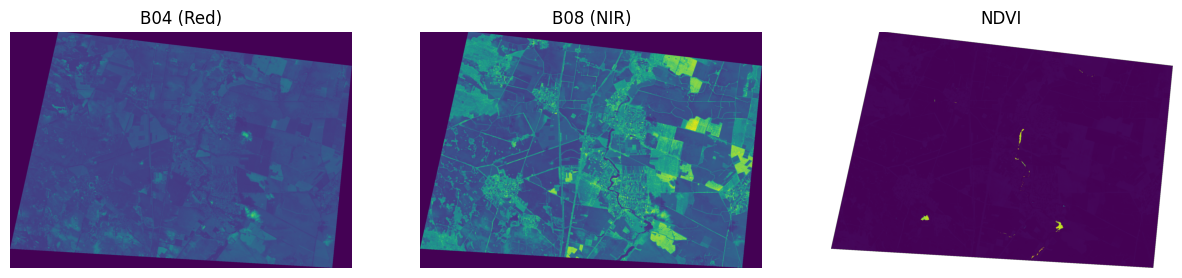

In [20]:
# AOI fragment loading
import geopandas as gpd
from rasterio.mask import mask

aoi = gpd.read_file("/content/drive/MyDrive/PhD/Знімки/aoi/aoi_zht.geojson")

aoi = aoi.to_crs("EPSG:32635")

points = gpd.read_file("/content/drive/MyDrive/PhD/Знімки/aoi/start_goal.geojson")
points = points.to_crs("EPSG:32635")

start = points.loc[points.role == "start"].geometry.iloc[0]
goal = points.loc[points.role == "goal"].geometry.iloc[0]

def read_image_aoi(path, aoi):

    with rasterio.open(path) as src:
        clipped, transform = mask(
            src,
            aoi.geometry,
            crop=True
        )
        return clipped[0]

b04 = read_image_aoi(b04_path, aoi)
b08 = read_image_aoi(b08_path, aoi)

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Plot B04
axes[0].imshow(b04)
axes[0].set_title('B04 (Red)')
axes[0].axis('off')

# Plot B08
axes[1].imshow(b08)
axes[1].set_title('B08 (NIR)')
axes[1].axis('off')


ndvi = (b08 - b04) / (b08 + b04)

# Plot B08
axes[2].imshow(ndvi)
axes[2].set_title('NDVI')
axes[2].axis('off')

plt.show()


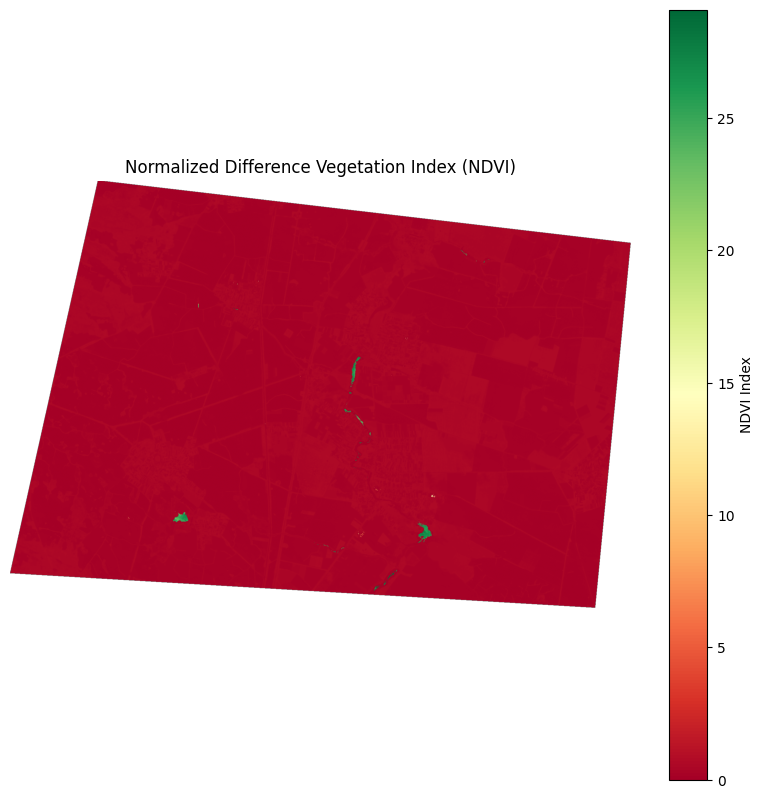